<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day08_practice2_CIFAR10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 컬러 이미지 ON - CIFAR-10

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("장치:", device)
EPOCHS = 10



장치: cuda


In [7]:
# [셀 1] 데이터 - CIFAR-10
# CIFAR-10 - 컬러 32x32 사진 10종 (pickle 배치 형식)

def load_dataset(root="./data"):
  tf = transforms.ToTensor()
  tr = datasets.CIFAR10(root, train=True, download=True, transform=tf) # 학습 5만장
  te = datasets.CIFAR10(root, train=False, download=True, transform=tf) # 테스트 1만장
  return tr, te

train_data, test_data = load_dataset()

100%|██████████| 170M/170M [37:48<00:00, 75.2kB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
이미지 모양: (C=3, H=32, W=32) | 클래스 10개


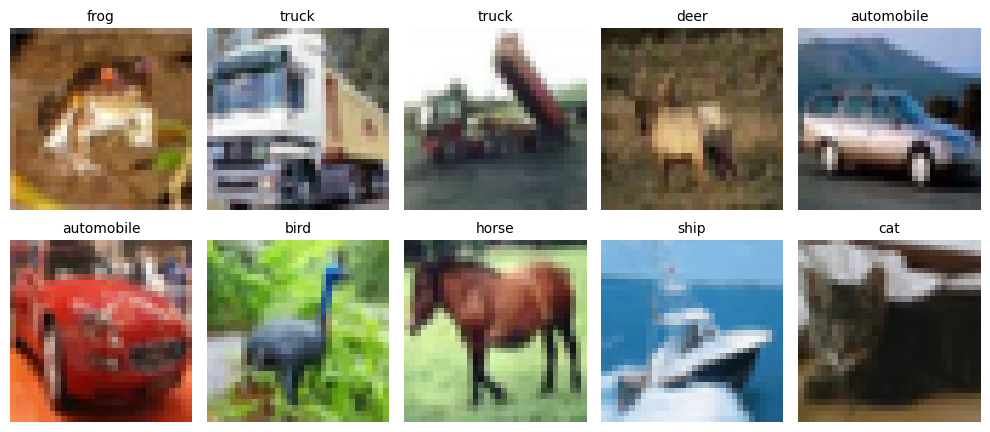

In [9]:
classes = train_data.classes

print(classes)

sample, _ = train_data[0]

C, H, W = sample.shape

print(f"이미지 모양: (C={C}, H={H}, W={W}) | 클래스 {len(classes)}개")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for i, ax in enumerate(axes.flat):

  img, label = train_data[i]

  ax.imshow(
      img.permute(1, 2, 0) if C == 3 else img[0],
      cmap=None if C == 3 else "gray"
  )

  ax.set_title(classes[label], fontsize=10)
  ax.axis("off")

plt.tight_layout()

plt.savefig("plot_samples.png")

plt.show()

In [11]:
# [셀 2] Normalize - 채널별 표준화
raw = torch.as_tensor(train_data.data).float() / 255.0 # 학습셋 전체 픽셀을 0-1로, ToTensor()가 하던 스케일링
mean = raw.mean(dim=(0,1,2))
std = raw.std(dim=(0,1,2))
print("측정한 채널별 평균", [round(v, 3) for v in mean.tolist()], "/표준편차", [round(v, 3) for v in std.tolist()])

norm = transforms.Normalize(tuple(mean.tolist()), tuple(std.tolist())) # 측정값으로 정규화 변환 생성
train_tf = transforms.Compose([transforms.ToTensor(), norm]) # ToTensor()(텐서화 + 0-1 스케일) 다음에 norm(표준화) 순서 규칙
test_tf = transforms.Compose([transforms.ToTensor(), norm])
train_data.transform = train_tf
test_data.transform = test_tf

train_loader = DataLoader(train_data, batch_size=128, shuffle=True) # 학습 로더
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)  # 테스트 로더


측정한 채널별 평균 [0.491, 0.482, 0.447] /표준편차 [0.247, 0.243, 0.262]


In [13]:
# [셀 3] CNN
class ColorCNN(nn.Module):
  def __init__(self, in_ch, img_size, n_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
    )
    feat = img_size // 4 # 풀링 2번으로 크기가 1/4, 특징맵 한 번 참여
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * feat * feat, 256), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(256, n_classes)               # 클래스 수만큼 출력
    )

  def forward(self, x):
    return self.classifier(self.features(x))

model = ColorCNN(C, H, len(classes)).to(device)
print("파라미터:", f"{sum(p.numel() for p in model.parameters()):,}개")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


파라미터: 1,116,970개


In [15]:
# [셀 4] 학습 + 평가
for epoch in range(EPOCHS):
  model.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    loss = loss_fn(model(images), labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  model.eval()
  correct = 0
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      correct += (model(images).argmax(1) == labels).sum().item() # 맞은 수 누적, argmax(1)은 가장 높은 점수의 클래스 번호
  print(f"epoch {epoch+1}/{EPOCHS} | 테스트 정확도 {correct/len(test_data):.4f}")

epoch 1/10 | 테스트 정확도 0.5983
epoch 2/10 | 테스트 정확도 0.6755
epoch 3/10 | 테스트 정확도 0.7186
epoch 4/10 | 테스트 정확도 0.7385
epoch 5/10 | 테스트 정확도 0.7572
epoch 6/10 | 테스트 정확도 0.7650
epoch 7/10 | 테스트 정확도 0.7556
epoch 8/10 | 테스트 정확도 0.7684
epoch 9/10 | 테스트 정확도 0.7683
epoch 10/10 | 테스트 정확도 0.7685


In [17]:
# [셀 5] 클래스와 정확도
n_cls = len(classes)
correct_c = torch.zeros(n_cls) #클래스별 맞은 수
total_c = torch.zeros(n_cls) # 전체 수 카운터
model.eval()
with torch.no_grad():
  for images, labels in test_loader:
    preds = model(images.to(device)).argmax(1).cpu() # 예측 클래스
    for t, p in zip(labels, preds):
      total_c[t] += 1
      if t == p: correct_c[t] += 1
print("\n[클래스별 정확도]")
for i, c in enumerate(classes):
  bar = "█" * int(correct_c[i] / total_c[i] * 20)
  print(f"{c:12s} {correct_c[i]/total_c[i]:.2f}{bar}")



[클래스별 정확도]
airplane     0.85█████████████████
automobile   0.87█████████████████
bird         0.59███████████
cat          0.58███████████
deer         0.79███████████████
dog          0.64████████████
frog         0.86█████████████████
horse        0.81████████████████
ship         0.86█████████████████
truck        0.84████████████████
